# Exercise 6
**Cristina Correa - 1819211867**


In this exercise, we will be experimenting with different dataset size to asses the
importance of collecting data for AI models. To do so, we will change the train test split to
have 30,50 % test split by changing the following

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from keras.layers import Input
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [2]:
# Load the California housing dataset
california_housing = fetch_california_housing()
data = pd.DataFrame(
    data=np.c_[california_housing["data"], california_housing["target"]],
    columns=california_housing["feature_names"] + ["target"],
)

# Select features and target variable
X = data.drop("target", axis=1)
y = data["target"]

# Experiment 1: 30% Test Split

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.3097 - val_loss: 0.6269
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5853 - val_loss: 0.4641
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5047 - val_loss: 0.4162
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4147 - val_loss: 0.4002
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3988 - val_loss: 0.3875
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3890 - val_loss: 0.3777
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3710 - val_loss: 0.3801
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3712 - val_loss: 0.3651
Epoch 9/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3689 - val_loss: 0.3760
Epoch 10/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3661 - val_loss: 0.3636
Epoch 11/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3671 - val_loss: 0.3569
Epoch 12/100
113/113 ━━━━━━━━━━━━━━━━━━━━

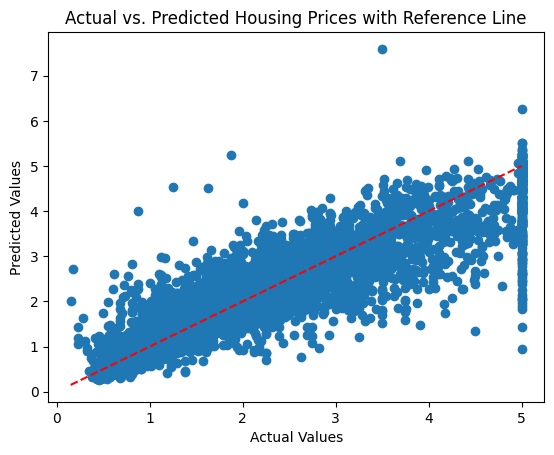

In [3]:
# Split the dataset into training and testing sets (30% test size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Standardise the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(units=512, activation="relu"))
model.add(Dense(units=1, activation="linear"))

# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

# Train the model
model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    verbose=1,
)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Root Mean Squared Error (30% Test Split):", rmse)

plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red"
)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Housing Prices with Reference Line")
plt.show()

----------------
# Experiment 2: 50% Test Split

Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.0671 - val_loss: 0.7373
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6969 - val_loss: 0.5769
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5472 - val_loss: 0.4813
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4653 - val_loss: 0.4404
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4144 - val_loss: 0.4257
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4231 - val_loss: 0.4033
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4005 - val_loss: 0.3940
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3953 - val_loss: 0.3888
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3949 - val_loss: 0.3851
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3769 - val_loss: 0.3855
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3724 - val_loss: 0.3797
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3

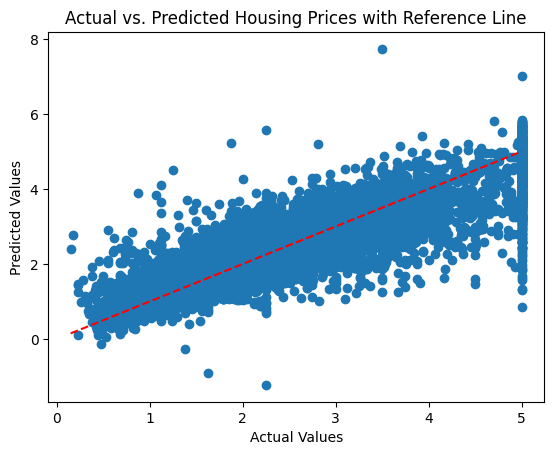

In [4]:
# Split the dataset into training and testing sets (50% test size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# Standardise the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(units=512, activation="relu"))
model.add(Dense(units=1, activation="linear"))

# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

# Train the model
model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    verbose=1,
)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Root Mean Squared Error (50% Test Split):", rmse)

plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red"
)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Housing Prices with Reference Line")
plt.show()

------------------
# Experiment 3: 15% Test Split 


Epoch 1/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.1936 - val_loss: 0.5910
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5410 - val_loss: 0.4596
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4213 - val_loss: 0.4176
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4256 - val_loss: 0.4025
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4052 - val_loss: 0.3962
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3820 - val_loss: 0.3878
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3718 - val_loss: 0.3809
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3697 - val_loss: 0.3727
Epoch 9/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3669 - val_loss: 0.3655
Epoch 10/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4514 - val_loss: 0.3585
Epoch 11/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3610 - val_loss: 0.3674
Epoch 12/100
138/138 ━━━━━━━━━━━━━━━━━━━━

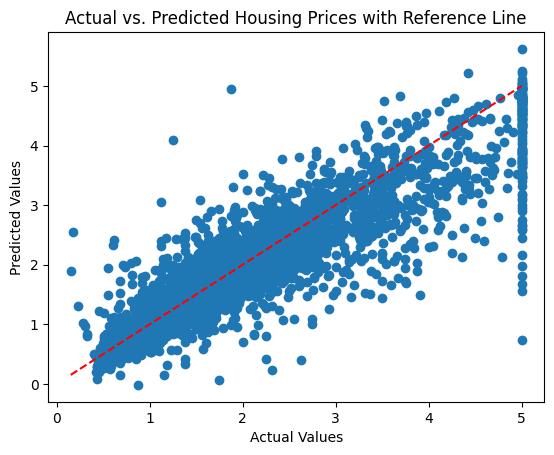

In [6]:
# Split the dataset into training and testing sets (15% test size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Standardise the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(units=512, activation="relu"))
model.add(Dense(units=1, activation="linear"))

# Compile the model
model.compile(optimizer="adam", loss="mean_squared_error")

# Train the model
model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_scaled, y_test),
    verbose=1,
)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Root Mean Squared Error (15% Test Split):", rmse)

plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red"
)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Housing Prices with Reference Line")
plt.show()